# Análisis exploratorio — StreamView Analytics

Registro del análisis que llevó a las decisiones del dashboard (ADY1104 · DUOC UC · Maicol Hernández · Francis Moya). Es la evidencia de la sección «Análisis exploratorio» del informe.

**Cómo leerlo.** Cuatro secciones: **A** carga e integración, **B** calidad de los datos, **C** distribuciones y **D** hallazgos que sustentan la tesis. Cada una termina con una celda **Conclusión** que dice qué se encontró y qué decisión de diseño generó en el dashboard. Los cálculos reutilizan `src/` (son los mismos que ve el dashboard, sin duplicar código) y los colores salen de `src/theme.py`: **rojo = Película, gris = Serie**.

**Cómo ejecutarlo.** Desde la raíz del proyecto: `jupyter nbconvert --to notebook --execute --inplace notebooks/analisis_exploratorio.ipynb`, o abrirlo en VS Code / Jupyter (necesita `ipykernel`). Los gráficos son imágenes estáticas hechas con kaleido, que usa el Chrome instalado (igual que `python -m src.exportar`).

**Sobre las cifras.** Las celdas Conclusión citan las cifras de esta ejecución (datos hasta 2025). La última celda del notebook las comprueba con `assert`: si los datos cambian, falla en lugar de dejar una conclusión desactualizada.

In [1]:
import logging
import sys
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir() and (p / "src").is_dir())
sys.path.insert(0, str(RAIZ))

import streamlit  # se importa primero para silenciar los avisos de st.cache_data fuera de `streamlit run`
for _nombre in list(logging.root.manager.loggerDict):
    if _nombre.startswith("streamlit"):
        logging.getLogger(_nombre).setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

from src import charts, data_loader, exportar, metrics, narrative, theme

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
FORMATOS = charts.FORMATOS  # ["Película", "Serie"]


def base(fig, alto=380):
    """Estilo común del dashboard (theme.aplicar_layout) con el alto y los márgenes de un gráfico suelto."""
    fig = theme.aplicar_layout(fig)
    fig.update_layout(height=alto, margin=dict(l=60, r=20, t=44, b=50))
    return fig


def mostrar(fig, titulo=None, subtitulo=""):
    """Muestra la figura como imagen estática, con su título-mensaje encima (igual que las imágenes de images/)."""
    if titulo:
        fig = exportar._con_titulo(fig, titulo, subtitulo)
    fig.show(renderer="png", width=exportar.ANCHO_PX, height=fig.layout.height, scale=1.5)


def en_cl(tabla, decimales=1):
    """Tabla con los números en formato es-CL (punto de miles, coma decimal), como en el dashboard."""
    return tabla.map(lambda v: theme.fmt_float(v, decimales) if isinstance(v, (float, np.floating))
                     else theme.fmt_int(v) if isinstance(v, (int, np.integer)) else v)


print(f"Proyecto: {RAIZ.name} · pandas {pd.__version__} · plotly {plotly.__version__}")

Proyecto: StreamView_Analytics-main · pandas 2.3.3 · plotly 7.1.0


## A. Carga e integración de los dos CSV

In [2]:
crudo = {
    "Película": pd.read_csv(data_loader.RUTA_DATOS / data_loader.ARCHIVO_PELICULAS),
    "Serie": pd.read_csv(data_loader.RUTA_DATOS / data_loader.ARCHIVO_SERIES),
}
archivos = {"Película": data_loader.ARCHIVO_PELICULAS, "Serie": data_loader.ARCHIVO_SERIES}
pd.DataFrame({
    f: {"archivo": archivos[f], "filas": len(d), "columnas": d.shape[1], "años de estreno": f"{d.release_year.min()}–{d.release_year.max()}"}
    for f, d in crudo.items()
}).T

,archivo,filas,columnas,años de estreno
Película,netflix_movies_detailed_up_to_2025.csv,16000,18,2010–2025
Serie,netflix_tv_shows_detailed_up_to_2025.csv,16000,16,2010–2025


In [3]:
solo_peliculas = sorted(set(crudo["Película"].columns) - set(crudo["Serie"].columns))
solo_series = sorted(set(crudo["Serie"].columns) - set(crudo["Película"].columns))
print("Columnas solo en el archivo de películas:", solo_peliculas)
print("Columnas solo en el archivo de series:   ", solo_series or "ninguna")
print("\nDe las columnas en común, el dashboard usa: title, type, release_year, popularity, vote_count, vote_average, genres y country.")

# Integración: la misma que hace el dashboard (une los CSV, convierte géneros y países en listas sin repetidos y los traduce)
df, generos, paises = data_loader.load_data()
anio_max = int(df["release_year"].max())
assert len(df) == sum(len(d) for d in crudo.values())
print(f"\nCatálogo integrado: {theme.fmt_int(len(df))} títulos · {len(generos)} géneros · {len(paises)} países · estrenos {df.release_year.min()}–{anio_max}")
df.head(4)

Columnas solo en el archivo de películas: ['budget', 'revenue']
Columnas solo en el archivo de series:    ninguna

De las columnas en común, el dashboard usa: title, type, release_year, popularity, vote_count, vote_average, genres y country.



Catálogo integrado: 32.000 títulos · 28 géneros · 147 países · estrenos 2010–2025


,title,type,release_year,date_added,duration,language,budget,revenue,popularity,vote_count,vote_average,generos,paises
0,Shrek Forever After,Película,2010,2010-05-16,NaN,en,165000000.0,752600867.0,203.893,7449,6.380,"[Comedia, Aventura, Fantasía, Animación, Famil...",[Estados Unidos]
1,Inception,Película,2010,2010-07-15,NaN,en,160000000.0,839030630.0,156.242,37119,8.369,"[Acción, Ciencia ficción, Aventura]","[Reino Unido, Estados Unidos]"
2,Harry Potter and the Deathly Hallows: Part 1,Película,2010,2010-11-17,NaN,en,250000000.0,954305868.0,121.191,19327,7.744,"[Aventura, Fantasía]","[Reino Unido, Estados Unidos]"
3,Tangled,Película,2010,2010-11-24,NaN,en,260000000.0,592461732.0,111.762,11638,7.600,"[Animación, Familiar, Aventura]",[Estados Unidos]


### Conclusión A

**Qué se encontró.** Dos archivos con la misma estructura: 16.000 películas y 16.000 series estrenadas entre 2010 y 2025. Solo `budget` y `revenue` existen únicamente en el archivo de películas, y ningún gráfico las necesita. Géneros y países vienen como texto separado por comas, con un orden que importa (el primer país es el principal).

**Decisión de diseño.** El *loader* (`src/data_loader.py`) une los archivos, convierte géneros y países en listas **sin repetidos y respetando el orden del origen**, y los traduce al español al cargar, para que filtros, títulos y gráficos usen los mismos nombres. `budget`, `revenue` y otras columnas se conservan sin usar. Los 32.000 títulos son el universo del popover «ⓘ Sobre los datos» y de `docs/metodologia.md`.

## B. Diagnóstico de calidad de los datos

Cinco preguntas sobre los datos antes de graficar nada. Cada hallazgo tiene un gráfico o una tabla.

### B1. Títulos por año y formato: ¿el reparto es natural?

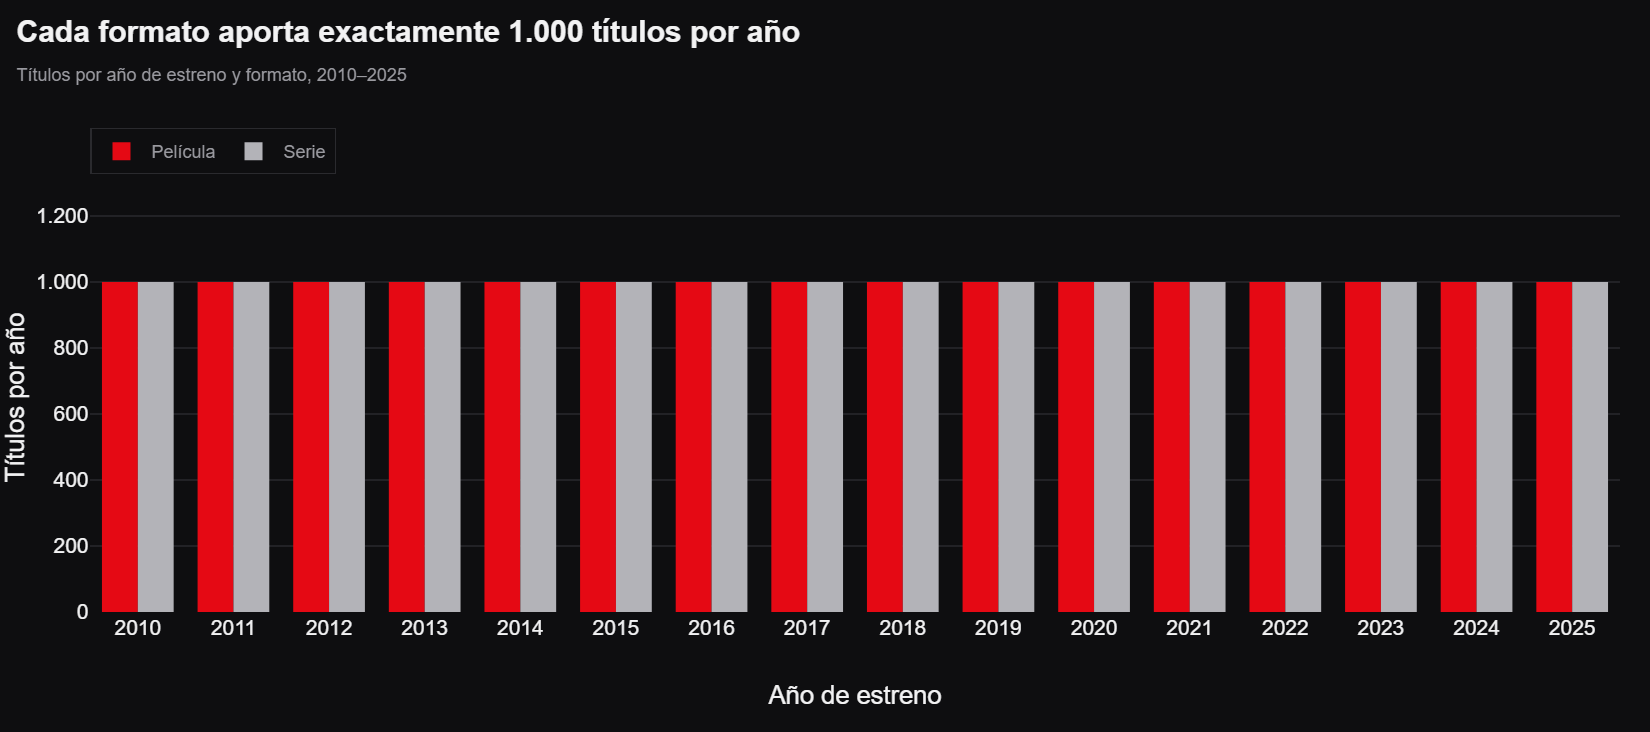

Valores distintos de «títulos por año y formato»: [np.int64(1000)]
Reparto uniforme (mismo conteo en las 32 combinaciones y 50/50 entre formatos): True


In [4]:
pc = metrics.perfil_catalogo(df, anio_max)  # hechos del catálogo completo (los mismos que cita la metodología: popover y docs/metodologia.md)
por_anio = df.groupby(["release_year", "type"]).size().rename("titulos").reset_index()

fig = go.Figure()
for f in FORMATOS:
    d = por_anio[por_anio["type"] == f]
    fig.add_trace(go.Bar(x=d["release_year"], y=d["titulos"], name=f, marker_color=theme.COLOR_FORMATO[f],
                         hovertemplate="%{x}: %{y:,} títulos<extra>" + f + "</extra>"))
fig = base(fig)
fig.update_layout(barmode="group", bargap=0.25, legend=dict(x=0, xanchor="left"))
fig.update_xaxes(dtick=1, title_text="Año de estreno")
fig.update_yaxes(range=[0, 1300], showgrid=True, title_text="Títulos por año", tickformat=",")
mostrar(fig, f"Cada formato aporta exactamente {theme.fmt_int(pc['filas_por_anio_formato'])} títulos por año",
        f"Títulos por año de estreno y formato, {pc['anio_min']}–{pc['anio_max']}")

print(f"Valores distintos de «títulos por año y formato»: {sorted(por_anio.titulos.unique())}")
print(f"Reparto uniforme (mismo conteo en las {len(por_anio)} combinaciones y 50/50 entre formatos): {pc['uniforme']}")

**Conclusión B1.** *Qué se encontró:* las 32 combinaciones año × formato tienen **exactamente 1.000 títulos**, y los dos formatos suman lo mismo (16.000). Un reparto tan regular no es natural: los datos parecen sintéticos o muestreados por cuotas. *Decisión de diseño:* el dashboard **no analiza cuántos títulos se estrenan por año** (ninguna serie temporal de volumen) y queda declarado como limitación en «ⓘ Sobre los datos» y en `docs/metodologia.md`; solo se comparan popularidad y valoración.

### B2. `rating` frente a `vote_average`: ¿es una clasificación etaria?

,tipo de dato de rating,rating mín–máx,rating sin valor,filas donde rating ≠ vote_average
Película,float64,0–10,0,0
Serie,float64,0–10,0,0


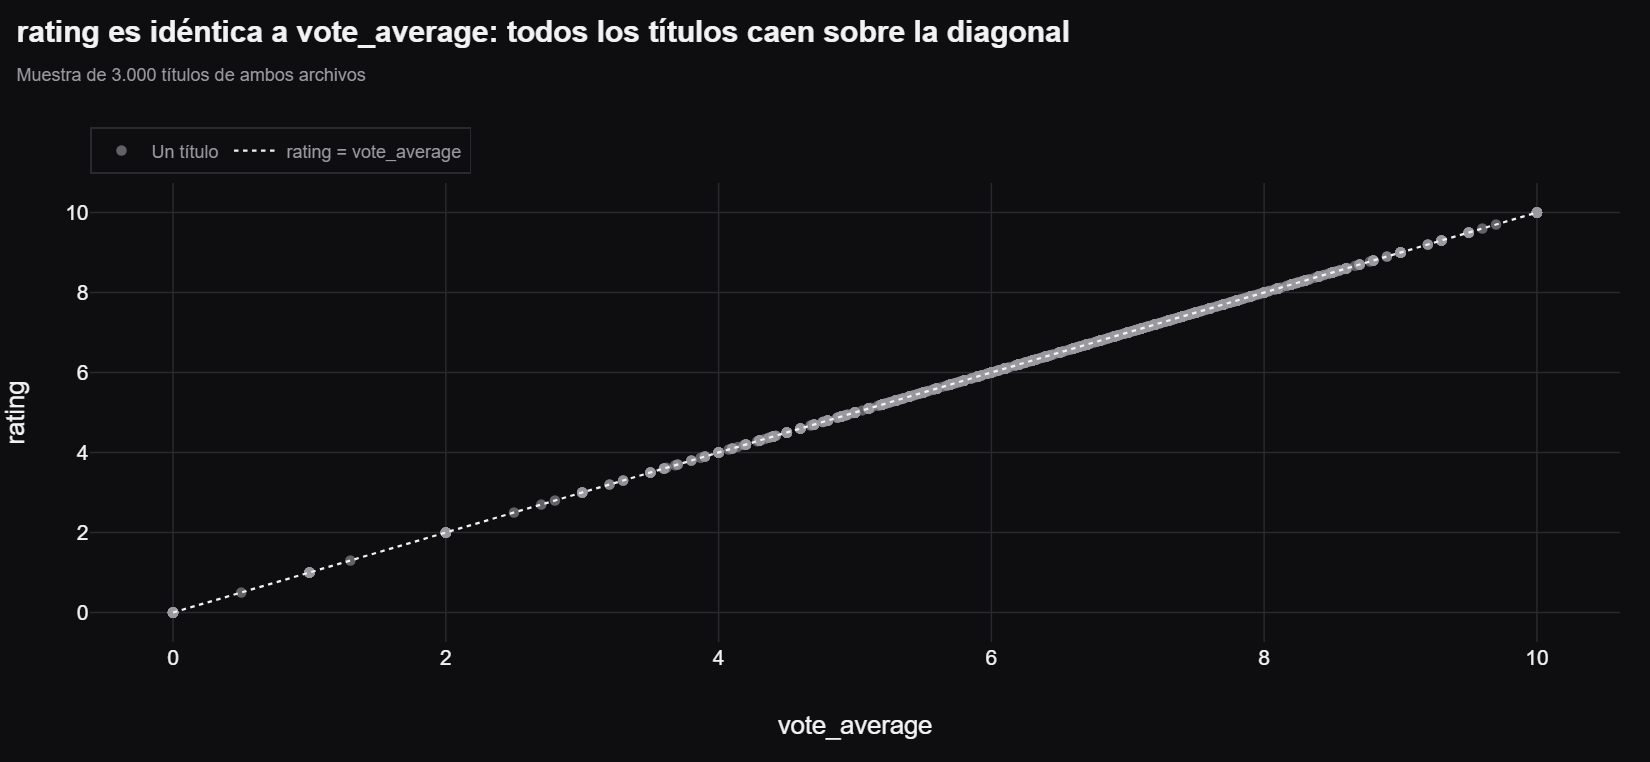

perfil_fuente(): {'rating_numerico': True, 'rating_igual_vote_average': True, 'rating_min': 0.0, 'rating_max': 10.0}


In [5]:
fuente = data_loader.perfil_fuente()  # lo que el dashboard comprueba leyendo los CSV crudos
tabla_rating = pd.DataFrame({
    f: {
        "tipo de dato de rating": str(d["rating"].dtype),
        "rating mín–máx": f"{d['rating'].min():g}–{d['rating'].max():g}",
        "rating sin valor": int(d["rating"].isna().sum()),
        "filas donde rating ≠ vote_average": int((d["rating"].fillna(-1) != d["vote_average"].fillna(-1)).sum()),
    }
    for f, d in crudo.items()
}).T
display(tabla_rating)

muestra = pd.concat(crudo.values()).sample(3000, random_state=1)
fig = go.Figure()
fig.add_trace(go.Scatter(x=muestra["vote_average"], y=muestra["rating"], mode="markers", name="Un título",
                         marker=dict(size=7, color=theme.TEXT_MUTED, opacity=0.6)))
fig.add_trace(go.Scatter(x=[0, 10], y=[0, 10], mode="lines", name="rating = vote_average",
                         line=dict(color=theme.TEXT, dash="dot", width=1.5)))
fig = base(fig, alto=400)
fig.update_layout(legend=dict(x=0, xanchor="left"))
fig.update_xaxes(showgrid=True, title_text="vote_average")
fig.update_yaxes(showgrid=True, title_text="rating")
mostrar(fig, "rating es idéntica a vote_average: todos los títulos caen sobre la diagonal", "Muestra de 3.000 títulos de ambos archivos")
print("perfil_fuente():", {k: fuente[k] for k in ("rating_numerico", "rating_igual_vote_average", "rating_min", "rating_max")})

**Conclusión B2.** *Qué se encontró:* `rating` es **numérica (0 a 10) y coincide con `vote_average` en las 32.000 filas**, en los dos archivos, sin un solo valor distinto. No trae categorías como TV-MA o PG. *Decisión de diseño:* se **descartó `rating`** y no hay análisis por audiencia por edad (el gráfico de segmentos de audiencia de la primera versión no tenía base en los datos). `docs/metodologia.md` declara que `rating` no es una clasificación etaria, y esa frase se genera comprobando los archivos, no escribiéndola.

### B3. Géneros por formato: ¿las películas y las series comparten taxonomía?

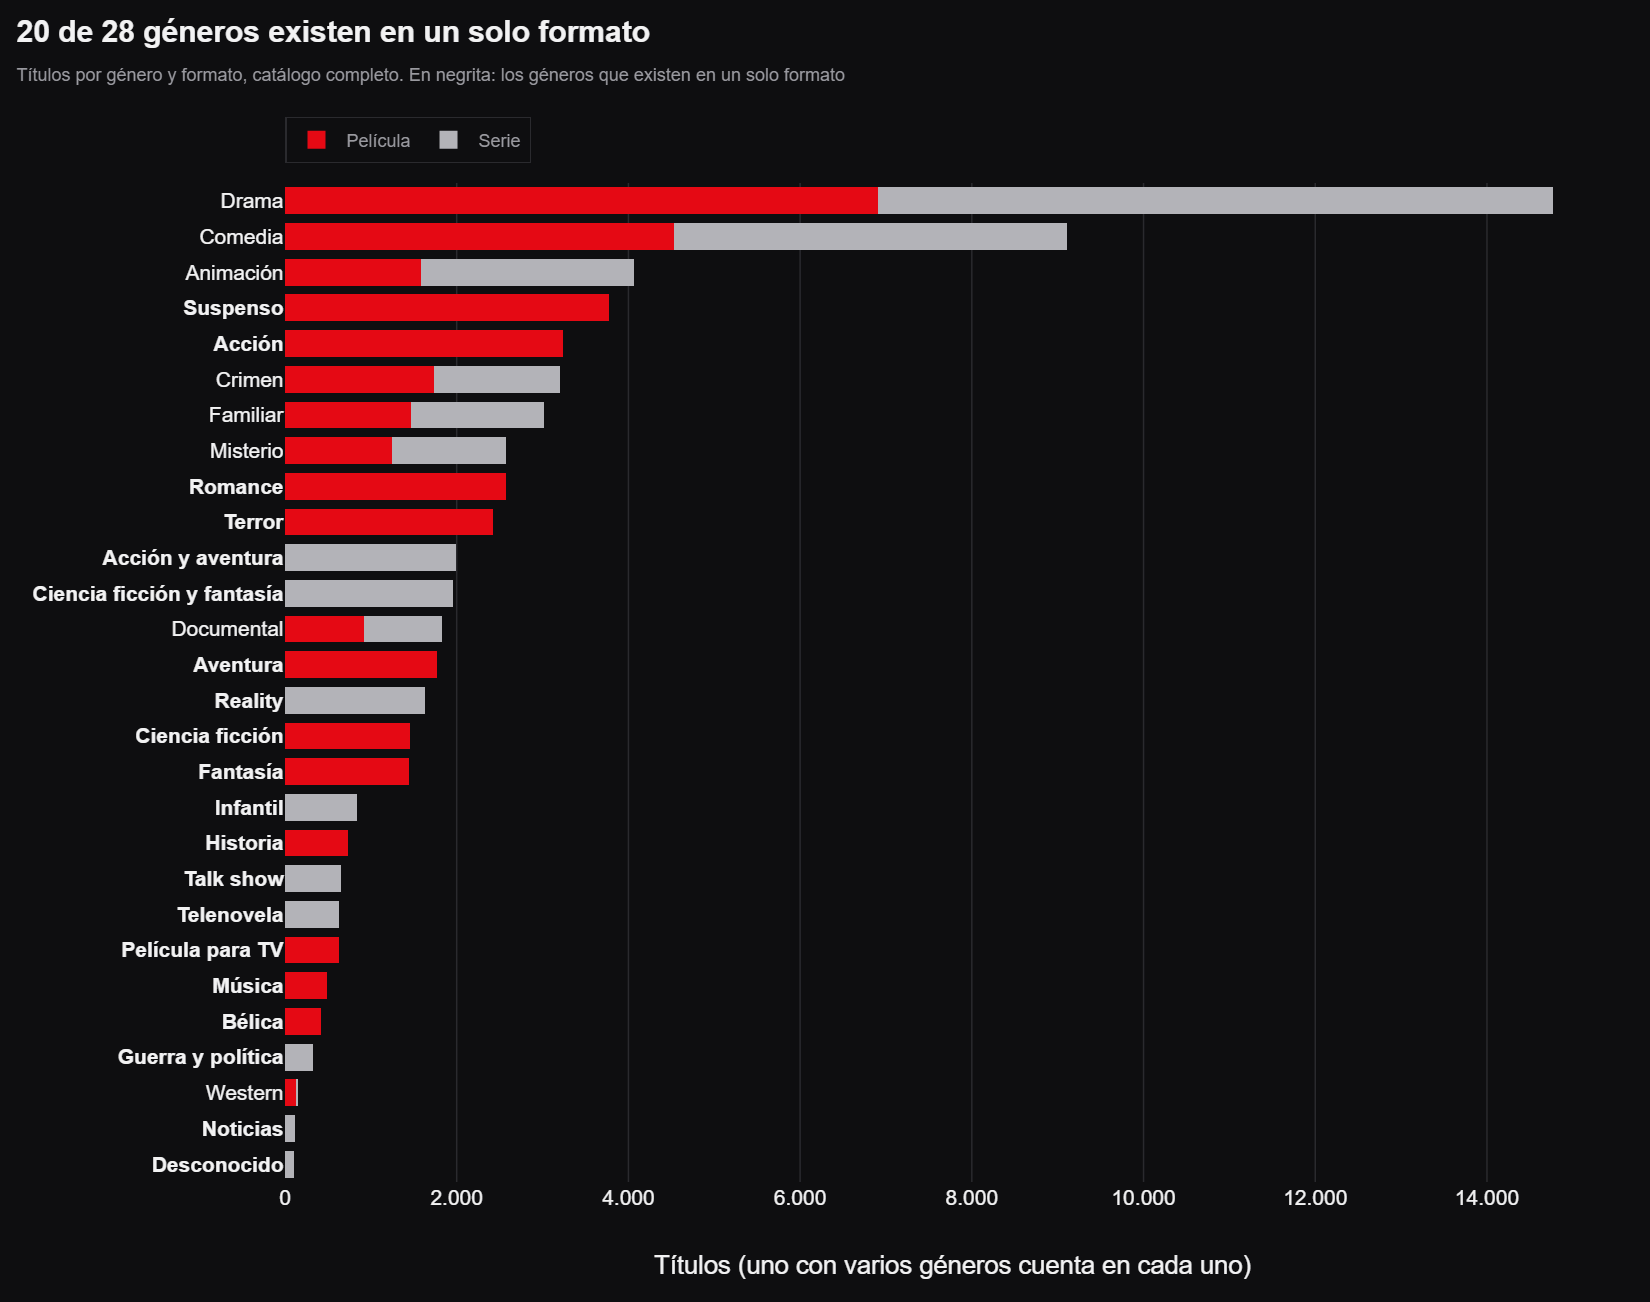

Solo en películas (11): Acción, Aventura, Bélica, Ciencia ficción, Fantasía, Historia, Música, Película para TV, Romance, Suspenso y Terror
Solo en series (9): Acción y aventura, Ciencia ficción y fantasía, Desconocido, Guerra y política, Infantil, Noticias, Reality, Talk show y Telenovela

Títulos que repiten una etiqueta de género: 13 (ejemplos: ['Animation, Animation, Mystery, Crime', 'Mystery, Sci-Fi & Fantasy, Drama, Mystery', 'Comedy, Drama, Unknown, Unknown']). El loader los deduplica.


In [6]:
# Los 28 géneros, sin mínimo de títulos (resumen_generos devuelve las columnas «Película» y «Serie»)
todos = metrics.resumen_generos(df, n=len(generos), min_titulos=1)
todos = todos.assign(total=todos["Película"] + todos["Serie"]).sort_values("total")
exclusivos = set(pc["generos_un_formato"])

fig = go.Figure()
for f in FORMATOS:
    fig.add_trace(go.Bar(y=todos["genero"], x=todos[f], name=f, orientation="h", marker_color=theme.COLOR_FORMATO[f],
                         hovertemplate="%{y}: %{x:,} títulos<extra>" + f + "</extra>"))
fig = base(fig, alto=760)
fig.update_layout(barmode="stack", bargap=0.25, legend=dict(x=0, xanchor="left", traceorder="normal"), margin=dict(l=190, r=20, t=44, b=50))
fig.update_yaxes(categoryorder="array", categoryarray=list(todos["genero"]), tickmode="array", tickvals=list(todos["genero"]),
                 ticktext=[f"<b>{g}</b>" if g in exclusivos else g for g in todos["genero"]])
fig.update_xaxes(showgrid=True, tickformat=",", title_text="Títulos (uno con varios géneros cuenta en cada uno)")
mostrar(fig, f"{len(exclusivos)} de {pc['n_generos']} géneros existen en un solo formato",
        "Títulos por género y formato, catálogo completo. En negrita: los géneros que existen en un solo formato")

solo_pel = todos[todos["Serie"] == 0]["genero"].tolist()
solo_ser = todos[todos["Película"] == 0]["genero"].tolist()
print(f"Solo en películas ({len(solo_pel)}): {narrative.unir_es(sorted(solo_pel))}")
print(f"Solo en series ({len(solo_ser)}): {narrative.unir_es(sorted(solo_ser))}")

# Aparte: etiquetas de género repetidas dentro de un mismo título (p. ej. «Comedy, Comedy»)
etiquetas = pd.concat(crudo.values())["genres"].fillna("").map(lambda v: [x.strip() for x in v.split(",") if x.strip()])
repetidos = etiquetas.map(len) != etiquetas.map(lambda xs: len(set(xs)))
print(f"\nTítulos que repiten una etiqueta de género: {int(repetidos.sum())} (ejemplos: {etiquetas[repetidos].head(3).map(', '.join).tolist()}). El loader los deduplica.")

**Conclusión B3.** *Qué se encontró:* **20 de los 28 géneros existen en un solo formato**: el origen usa categorías distintas para películas («Action», «Adventure», «Thriller»…) y para series («Action & Adventure», «Sci-Fi & Fantasy», «Soap», «Talk»…). Además, un puñado de títulos repite la misma etiqueta de género. *Decisión de diseño:* (1) los géneros de cada formato **se traducen por separado y no se fusionan**; (2) para comparar géneros y mercados se usa la **popularidad relativa a su formato** (cada título dividido por la mediana de su formato), porque las series son mucho más populares que las películas y un género que existe en un solo formato heredaría esa diferencia; (3) el gráfico de Géneros **colorea por el formato de origen** (excepción documentada) y su nota dice cuántos géneros existen en un solo formato; (4) el loader deduplica las etiquetas repetidas.

### B4. El año 2025: ¿es comparable con los anteriores?

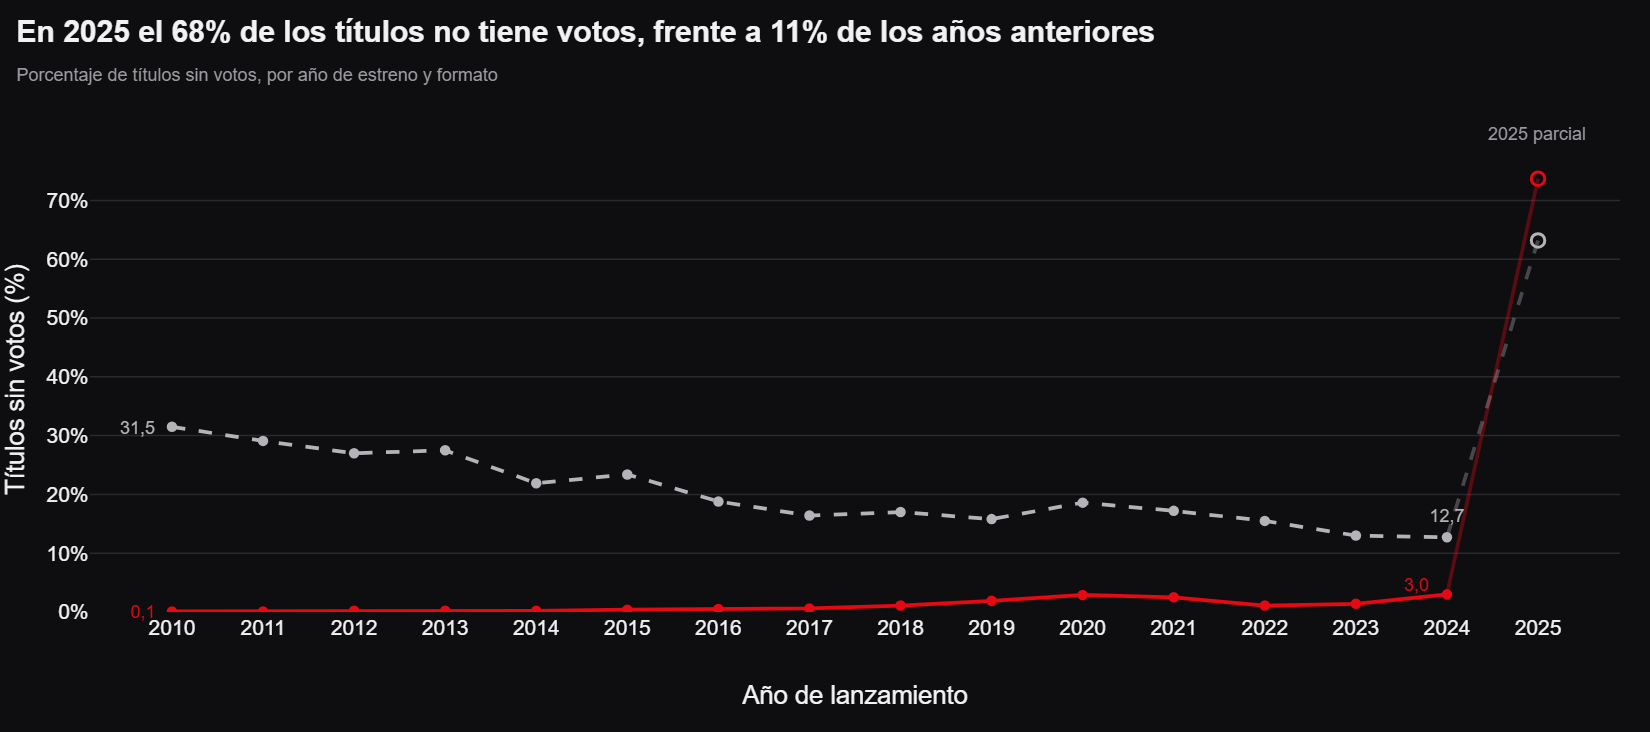

,2025 (año parcial),Años anteriores (2010–2024)
Títulos sin votos,68%,11%
Popularidad mediana,"9,8","23,0"


In [7]:
sin_votos = (
    (metrics.clasificar_valoracion(df) == metrics.NIVEL_SIN_VOTOS).groupby([df["release_year"], df["type"]]).mean().mul(100)
    .rename("valor").reset_index()
)
p = pc["parcial"]
fig = charts.linea_evolucion(sin_votos, "Títulos sin votos (%)", anio_parcial=anio_max)  # el mismo gráfico de líneas del dashboard
fig.update_yaxes(ticksuffix="%", hoverformat=".1f")
mostrar(fig, f"En {anio_max} el {theme.fmt_pct(p['pct_sin_votos'])} de los títulos no tiene votos, frente a {theme.fmt_pct(p['pct_sin_votos_previos'])} de los años anteriores",
        "Porcentaje de títulos sin votos, por año de estreno y formato")

pd.DataFrame({
    f"{anio_max} (año parcial)": [theme.fmt_pct(p["pct_sin_votos"]), theme.fmt_float(p["popularidad_mediana"])],
    f"Años anteriores ({pc['anio_min']}–{anio_max - 1})": [theme.fmt_pct(p["pct_sin_votos_previos"]), theme.fmt_float(p["popularidad_mediana_previos"])],
}, index=["Títulos sin votos", "Popularidad mediana"])

**Conclusión B4.** *Qué se encontró:* 2025 es un año **incompleto en la práctica**: sus títulos aún no acumulan votos (68 % sin votos contra 11 % en los años anteriores) y su popularidad mediana es 9,8 contra 23,0. Ambos formatos se desploman en el mismo punto, así que no es un efecto de un formato. *Decisión de diseño:* 2025 **se muestra, pero se marca como parcial** y queda fuera de los extremos de toda tendencia (el primer y el último año *completo*, 2015 y 2024): en Evolución el tramo hacia él va tenue, con marcador hueco y la anotación «2025 parcial»; en la tabla de títulos en riesgo lleva «(año parcial)». La nota de Evolución aclara que el 1,5× de 2025 no es una recuperación.

### B5. Coproducciones y títulos sin país

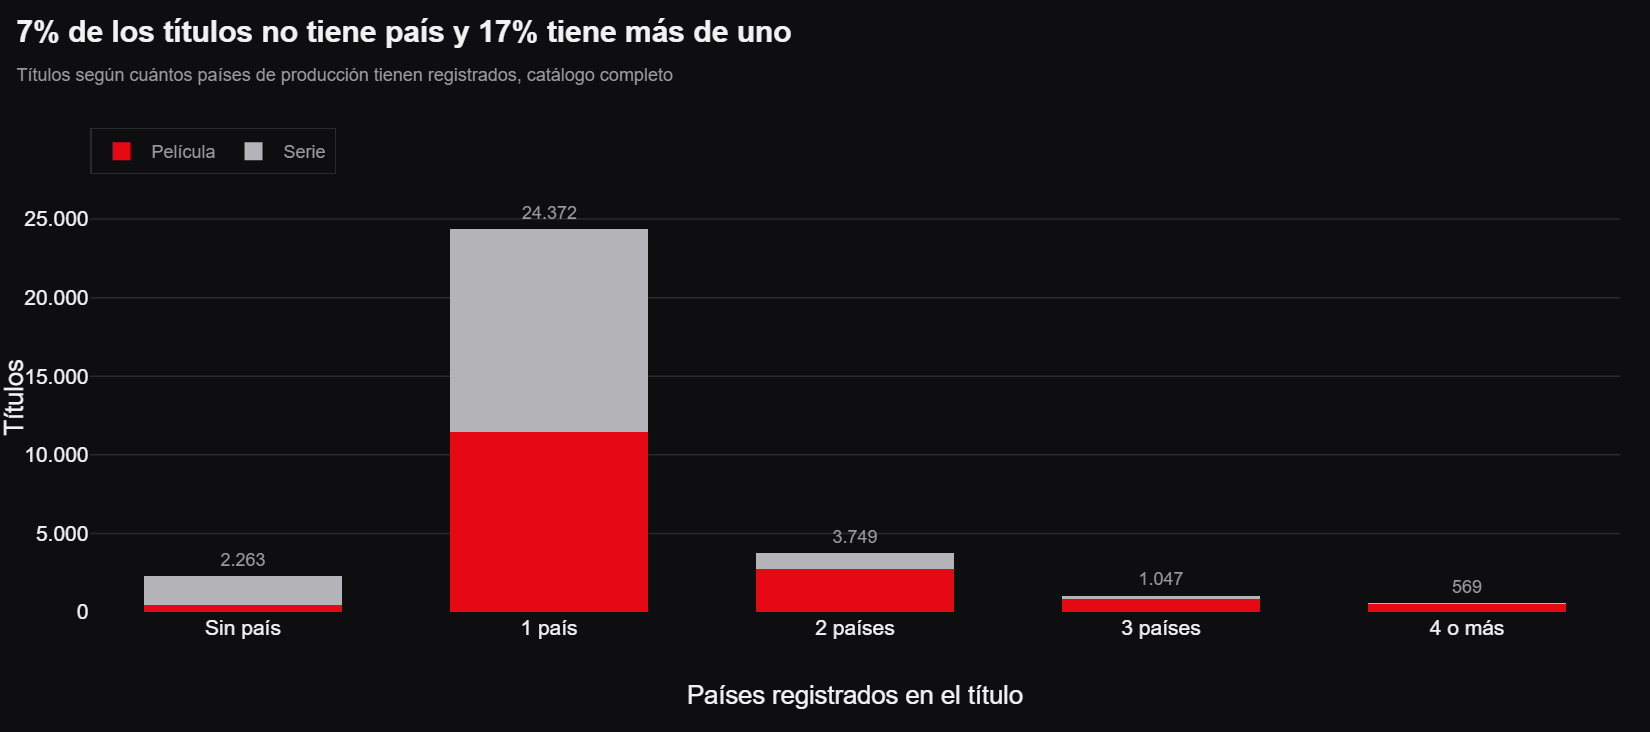

,Película,Serie,% de las películas,% de las series
paises,,,,
Sin país,466,1.797,3%,11%
1 país,11.476,12.896,72%,81%
2 países,2.723,1.026,17%,6%
3 países,854,193,5%,1%
4 o más,481,88,3%,1%


In [8]:
n_paises = df["paises"].map(len)
orden = ["Sin país", "1 país", "2 países", "3 países", "4 o más"]
etiqueta = n_paises.clip(upper=4).map(dict(enumerate(orden)))
conteo = pd.crosstab(etiqueta, df["type"]).reindex(orden)[FORMATOS]

fig = go.Figure([go.Bar(x=orden, y=conteo[f], name=f, marker_color=theme.COLOR_FORMATO[f],
                        hovertemplate="%{x}: %{y:,} títulos<extra>" + f + "</extra>") for f in FORMATOS])
for categoria, total in conteo.sum(axis=1).items():
    fig.add_annotation(x=categoria, y=total, text=theme.fmt_int(total), showarrow=False, yshift=11,
                       font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
fig = base(fig)
fig.update_layout(barmode="stack", bargap=0.35, legend=dict(x=0, xanchor="left", traceorder="normal"))
fig.update_xaxes(title_text="Países registrados en el título")
fig.update_yaxes(showgrid=True, tickformat=",", title_text="Títulos", range=[0, conteo.sum(axis=1).max() * 1.12])
mostrar(fig, f"{theme.fmt_pct(pc['n_sin_pais'] / pc['n_total'])} de los títulos no tiene país y {theme.fmt_pct(pc['n_multipais'] / pc['n_total'])} tiene más de uno",
        "Títulos según cuántos países de producción tienen registrados, catálogo completo")

por_formato = (conteo / conteo.sum()).map(theme.fmt_pct)
por_formato.columns = [f"% de las {f.lower()}s" for f in FORMATOS]
pd.concat([conteo.map(theme.fmt_int), por_formato], axis=1)

**Conclusión B5.** *Qué se encontró:* **2.263 títulos (7 %) no tienen país** (1.797 son series, 11 % de ellas, contra 3 % de las películas) y **5.365 (17 %) son coproducciones** con dos o más países, hasta 16. *Decisión de diseño:* Mercados ofrece **dos modos de conteo**: por defecto cada título cuenta una sola vez, en su primer país (los totales no superan al catálogo); con «Contar coproducciones en cada país» suma en todos sus países. Los porcentajes se calculan **sobre los títulos con país registrado**, y por eso solo esa pestaña muestra «Analizando N títulos con país registrado»: su denominador no coincide con el del indicador global.

## C. Distribuciones

### C1. `popularity`: forma de la distribución

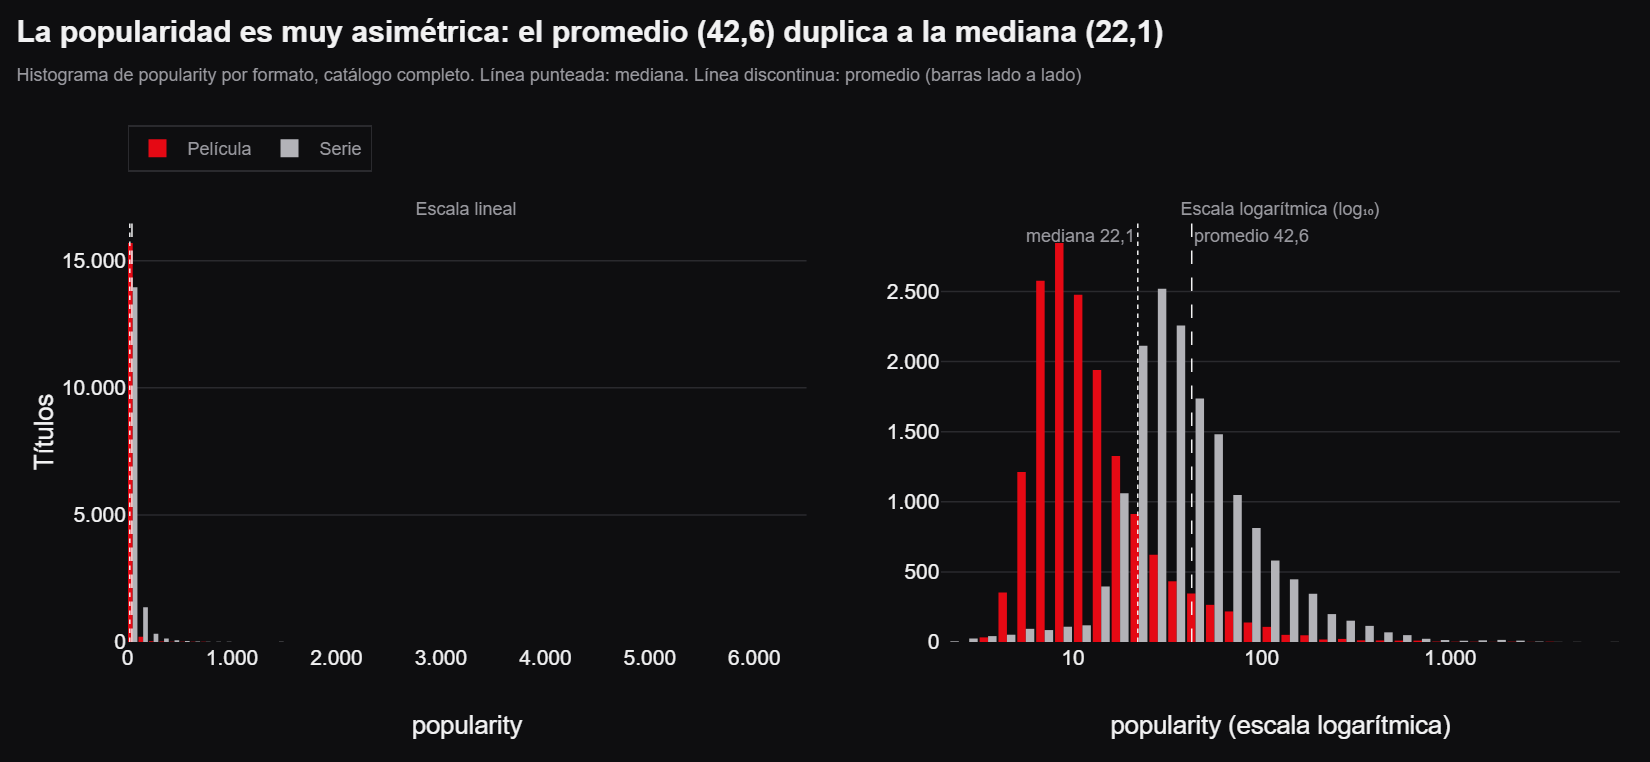

,promedio,mediana,p90,p99,máximo,asimetría (skew),% de títulos sobre su promedio
Película,"20,4","10,9","33,2","144,5","3.876,0","31,1","19,5"
Serie,"64,9","36,2","118,5","467,7","6.421,9","16,8","23,5"
Ambos,"42,6","22,1","81,5","346,7","6.421,9","20,1","24,3"


In [9]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Escala lineal", "Escala logarítmica (log₁₀)"), horizontal_spacing=0.09)
fig.update_annotations(font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
for f in FORMATOS:
    pop = df.loc[df["type"] == f, "popularity"]
    color = theme.COLOR_FORMATO[f]
    fig.add_trace(go.Histogram(x=pop, nbinsx=80, name=f, marker_color=color, legendgroup=f), row=1, col=1)
    fig.add_trace(go.Histogram(x=np.log10(pop), nbinsx=50, name=f, marker_color=color, legendgroup=f, showlegend=False), row=1, col=2)
mediana, promedio = df["popularity"].median(), df["popularity"].mean()
linea = dict(color=theme.TEXT, width=1)
fig.add_vline(x=mediana, line=dict(**linea, dash="dot"), row=1, col=1)
fig.add_vline(x=promedio, line=dict(**linea, dash="dash"), row=1, col=1)
fig.add_vline(x=np.log10(mediana), line=dict(**linea, dash="dot"), row=1, col=2, annotation_text=f"mediana {theme.fmt_float(mediana)}",
              annotation_position="top left", annotation_font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
fig.add_vline(x=np.log10(promedio), line=dict(**linea, dash="dash"), row=1, col=2, annotation_text=f"promedio {theme.fmt_float(promedio)}",
              annotation_position="top right", annotation_font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
fig = base(fig, alto=400)
fig.update_layout(barmode="group", bargap=0.1, legend=dict(x=0, xanchor="left", y=1.12), margin=dict(l=85, r=20, t=70, b=50))
fig.update_xaxes(title_text="popularity", tickformat=",", row=1, col=1)
fig.update_xaxes(title_text="popularity (escala logarítmica)", tickvals=[0, 1, 2, 3], ticktext=["1", "10", "100", "1.000"], row=1, col=2)
fig.update_yaxes(showgrid=True, tickformat=",", title_text="Títulos", row=1, col=1)
fig.update_yaxes(showgrid=True, tickformat=",", row=1, col=2)
mostrar(fig, f"La popularidad es muy asimétrica: el promedio ({theme.fmt_float(promedio)}) duplica a la mediana ({theme.fmt_float(mediana)})",
        "Histograma de popularity por formato, catálogo completo. Línea punteada: mediana. Línea discontinua: promedio (barras lado a lado)")

def resumen_pop(s):
    return pd.Series({"promedio": s.mean(), "mediana": s.median(), "p90": s.quantile(.90), "p99": s.quantile(.99), "máximo": s.max(),
                      "asimetría (skew)": s.skew(), "% de títulos sobre su promedio": (s > s.mean()).mean() * 100})

en_cl(pd.DataFrame({**{f: resumen_pop(df.loc[df["type"] == f, "popularity"]) for f in FORMATOS}, "Ambos": resumen_pop(df["popularity"])}).T)

**Conclusión C1.** *Qué se encontró:* `popularity` tiene una cola larguísima (máximo 6.422 con una mediana de 22): el promedio de 42,6 es casi el doble de la mediana de 22,1 y solo el 24 % de los títulos lo supera. La asimetría es 20 (una distribución simétrica daría 0). En escala logarítmica la forma se ordena y se ven bien los dos formatos: las series son ~3× más populares que las películas. *Decisión de diseño:* **todo el dashboard resume con la mediana, no con el promedio** (KPI, Evolución, géneros, mercados); la Matriz usa **escala logarítmica** en el eje de popularidad; y «ⓘ Sobre los datos» y `docs/metodologia.md` aclaran que `popularity` es un índice relativo de TMDB, útil para ordenar y comparar grupos pero no para medir audiencia absoluta.

### C2. `vote_average`: forma y cortes

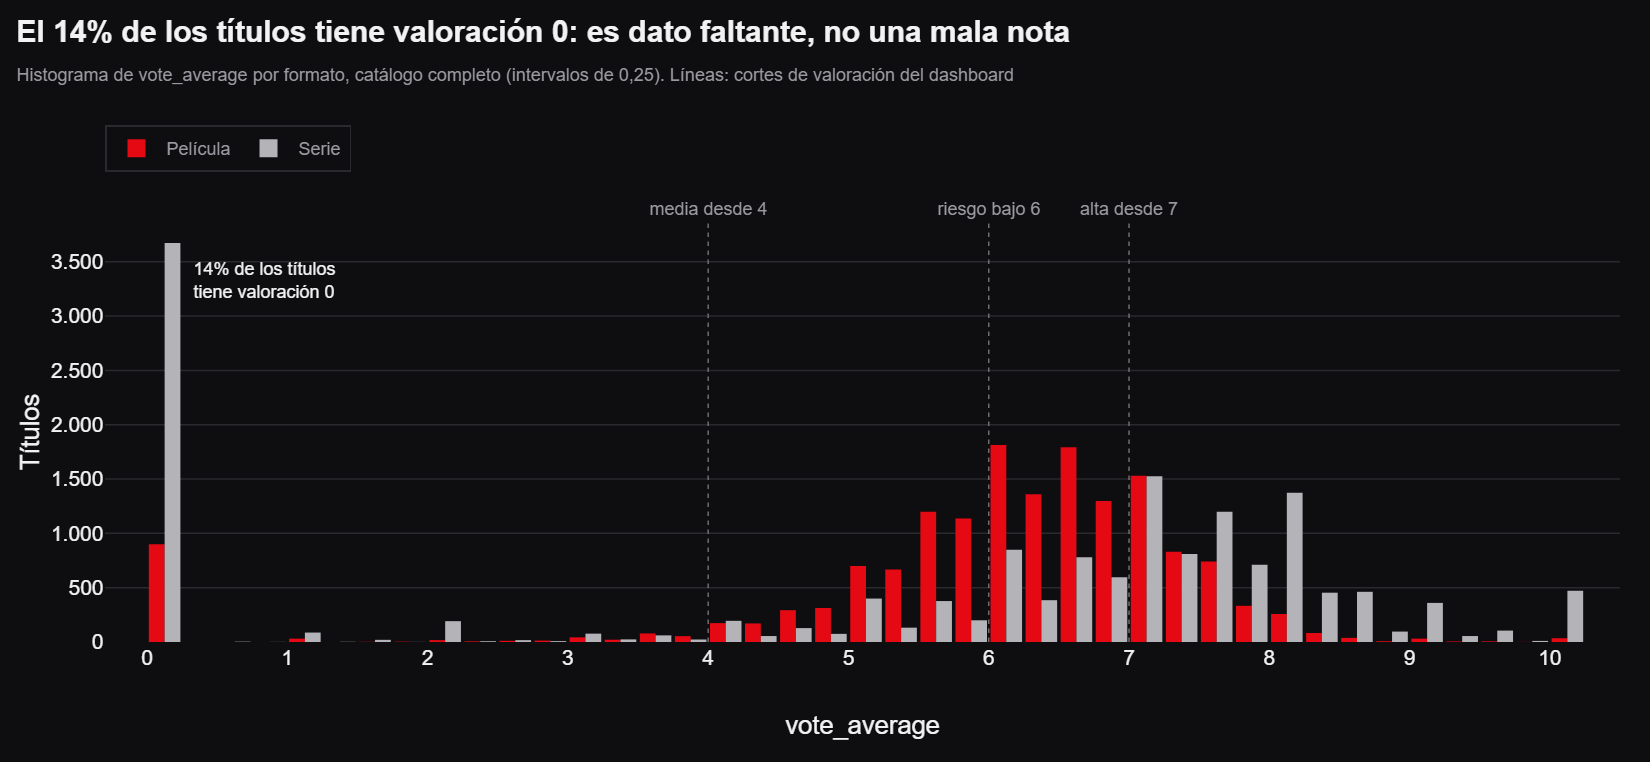

¿vote_average = 0 coincide con vote_count = 0?


vote_average = 0,False,True
vote_count = 0,,
False,27415,17
True,13,4555


Nivel,"Alta [7, 10]","Media [4, 7)","Baja [0, 4)",Sin votos
Formato,,,,
Película,24%,68%,2%,6%
Serie,48%,26%,3%,23%


In [10]:
pct_cero = (df["vote_average"] == 0).mean()
fig = go.Figure()
for f in FORMATOS:
    fig.add_trace(go.Histogram(x=df.loc[df["type"] == f, "vote_average"], xbins=dict(start=0, end=10.25, size=0.25), name=f,
                               marker_color=theme.COLOR_FORMATO[f]))
fig = base(fig, alto=400)
fig.update_layout(barmode="group", bargap=0.1, legend=dict(x=0, xanchor="left", y=1.12), margin=dict(l=70, r=20, t=70, b=50))
for corte, nombre in ((metrics.UMBRAL_MEDIA, "media desde"), (metrics.UMBRAL_RIESGO, "riesgo bajo"), (metrics.UMBRAL_ALTA, "alta desde")):
    fig.add_vline(x=corte, line=dict(color=theme.NEUTRO, dash="dot", width=1), annotation_text=f"{nombre} {corte}", annotation_position="top",
                  annotation_font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
fig.add_annotation(x=0.3, xref="x", y=0.92, yref="paper", xanchor="left", showarrow=False, align="left",
                   text=f"{theme.fmt_pct(pct_cero)} de los títulos<br>tiene valoración 0", font=dict(size=theme.TAM_CAPTION, color=theme.TEXT))
fig.update_xaxes(title_text="vote_average", dtick=1, range=[-0.3, 10.5])
fig.update_yaxes(showgrid=True, tickformat=",", title_text="Títulos")
mostrar(fig, f"El {theme.fmt_pct(pct_cero)} de los títulos tiene valoración 0: es dato faltante, no una mala nota",
        "Histograma de vote_average por formato, catálogo completo (intervalos de 0,25). Líneas: cortes de valoración del dashboard")

print("¿vote_average = 0 coincide con vote_count = 0?")
display(pd.crosstab(df["vote_count"] == 0, df["vote_average"] == 0, rownames=["vote_count = 0"], colnames=["vote_average = 0"]))
niveles = metrics.barras_valoracion(df).pivot(index="Formato", columns="Nivel", values="Porcentaje")
niveles.map(theme.fmt_pct)

**Conclusión C2.** *Qué se encontró:* el **14 % de los títulos tiene `vote_average` = 0**, y casi siempre es por lo mismo que `vote_count` = 0 (coinciden en 4.555 títulos; solo 30 difieren: 17 tienen votos pero valoración 0 y 13 al revés). No es una mala valoración, es ausencia de votos. Con votos, la mediana ronda 6,7 y la masa se concentra en la zona media y alta. *Decisión de diseño:* **«Sin votos» no es un nivel de valoración**: se define como `vote_count` = 0 **o** `vote_average` = 0 (el «o» cubre los 30 casos que no coinciden), va aparte y con trama rayada, y los porcentajes se calculan sobre el total de cada formato. Los cortes son baja [0, 4), media [4, 7) y alta [7, 10]; se define **riesgo como valoración bajo 6** (título popular mal evaluado), y las medias por año exigen un mínimo de votos (10 para la valoración mediana, 50 para la Matriz y el indicador «Catálogo bien evaluado»).

## D. Hallazgos que sustentan la tesis

Desde aquí se usan los **filtros por defecto del dashboard**: ambos formatos, todos los géneros y países, años 2015 a 2025. Es el conjunto con el que el dashboard abre y con el que se generan las imágenes de `images/`.

In [11]:
df_def = df[metrics.construir_mascara(df, "Ambos", [], [], (metrics.ANIO_INICIO_DEFECTO, anio_max))]
print(f"Selección por defecto: {theme.fmt_int(len(df_def))} títulos, {metrics.ANIO_INICIO_DEFECTO}–{anio_max}")

Selección por defecto: 22.000 títulos, 2015–2025


### D1. Razón de popularidad entre series y películas, por año

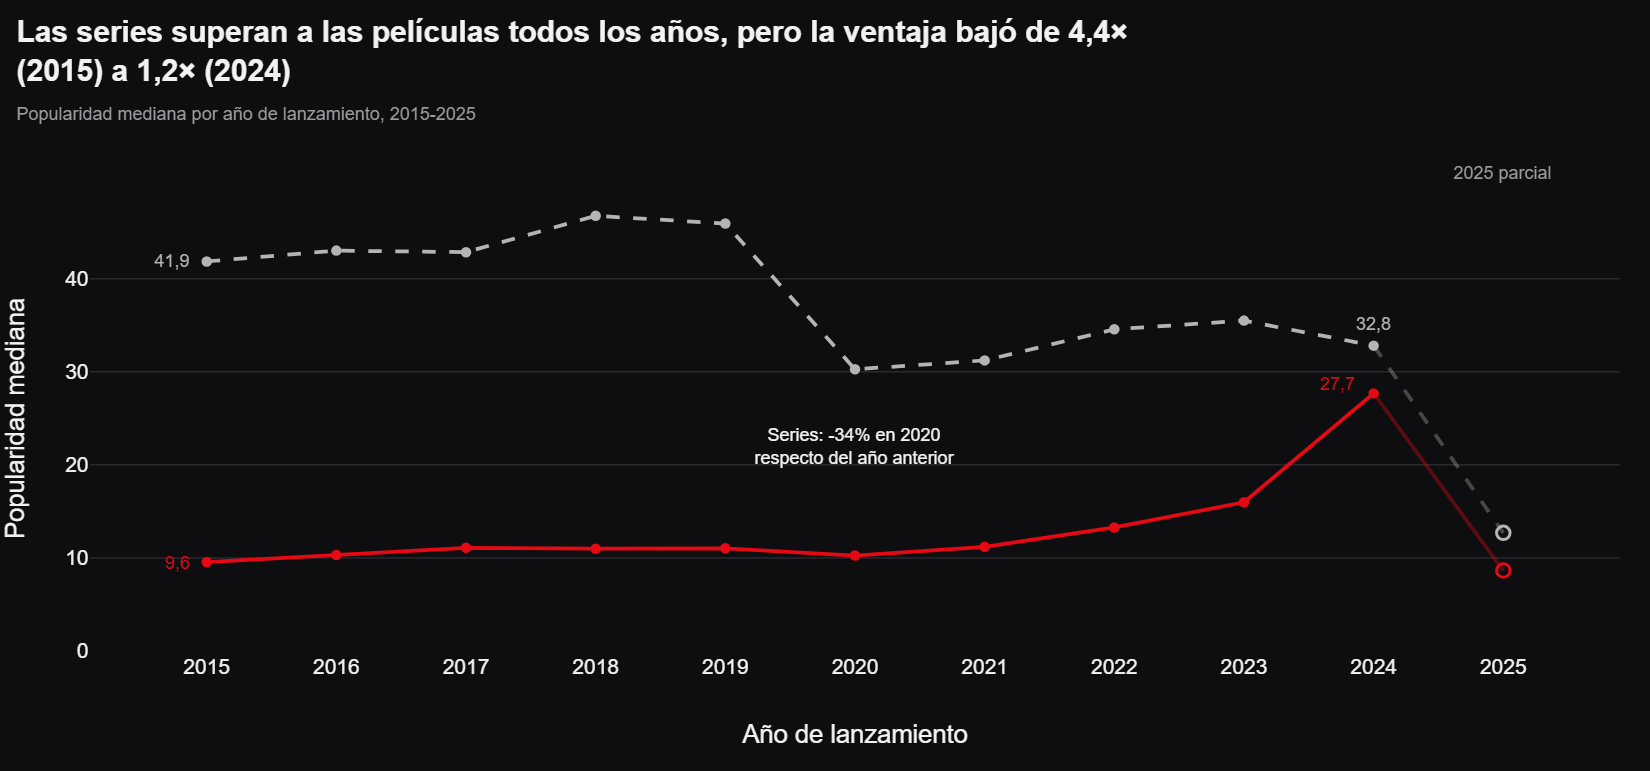

In [12]:
ev = metrics.evolucion_popularidad(df_def)
caida = metrics.variacion_anual(ev, "Serie", metrics.ANIO_ANOTADO)
caida = caida if caida is not None and caida <= -metrics.CAIDA_MINIMA_ANOTAR else None  # misma regla que aplica el dashboard
fig = charts.linea_evolucion(ev, "Popularidad mediana", anio_parcial=anio_max, caida=caida)
fig.update_yaxes(hoverformat=",.1f")
mostrar(fig, *narrative.titulo_evolucion(df_def, "Popularidad mediana", anio_max))

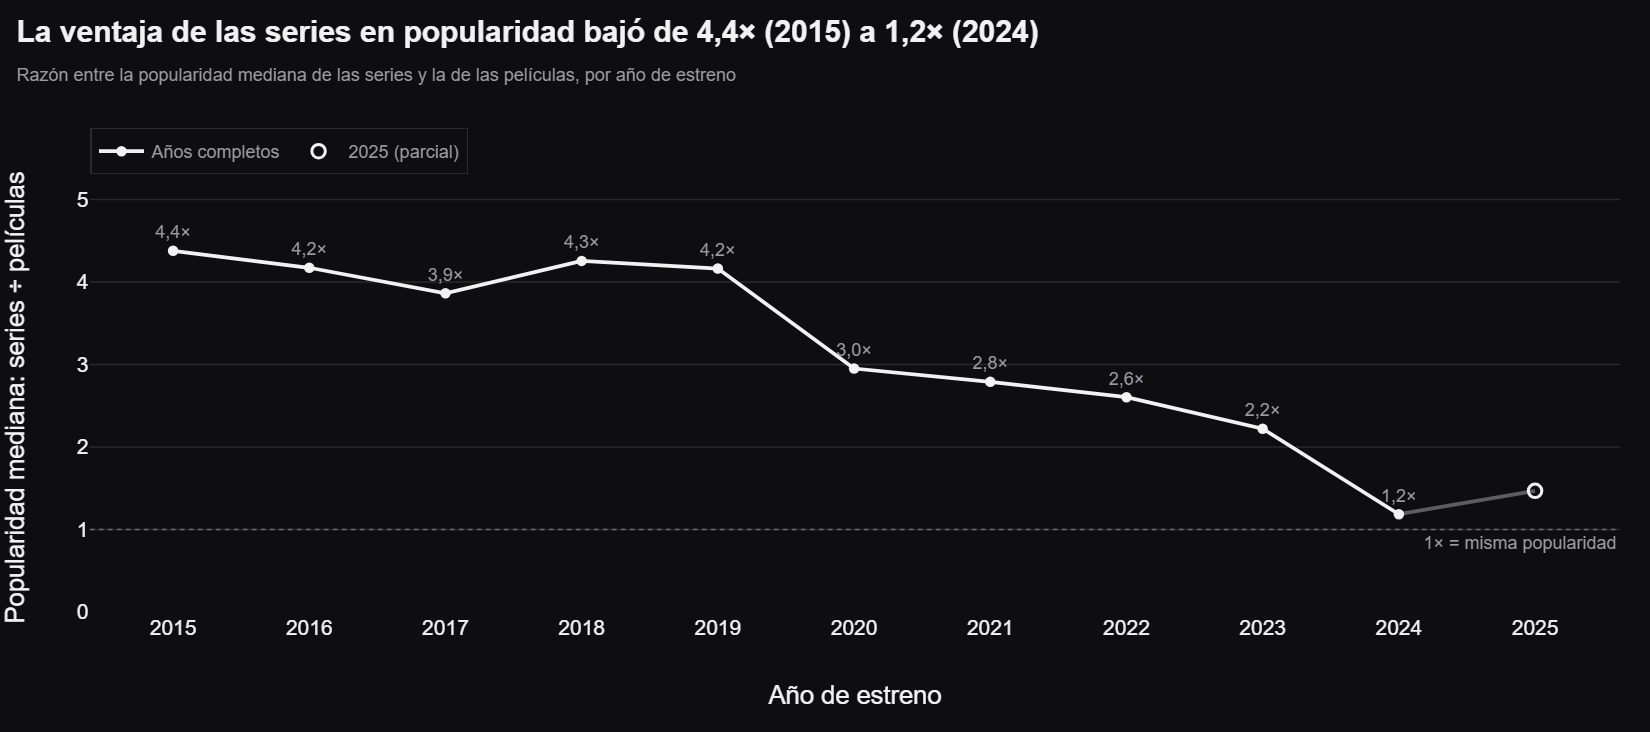

type,Año,Película,Serie,Series ÷ películas
0,2015,"9,56","41,85","4,38"
1,2016,"10,31","43,02","4,17"
2,2017,"11,09","42,85","3,86"
3,2018,"10,99","46,75","4,26"
4,2019,"11,03","45,92","4,16"
5,2020,"10,25","30,27","2,95"
6,2021,"11,19","31,22","2,79"
7,2022,"13,27","34,56","2,60"
8,2023,"15,98","35,50","2,22"
9,2024,"27,68","32,81","1,19"


In [13]:
razon = metrics.razon_por_anio(df_def)
completos, parcial = razon[razon["anio"] != anio_max], razon[razon["anio"] == anio_max]
fig = go.Figure()
fig.add_trace(go.Scatter(x=completos["anio"], y=completos["razon"], mode="lines+markers+text", name="Años completos",
                         line=dict(color=theme.TEXT, width=2.5), marker=dict(size=7, color=theme.TEXT),
                         text=[f"{theme.fmt_float(r)}×" for r in completos["razon"]], textposition="top center",
                         textfont=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED), hovertemplate="%{x}: %{y:.2f}×<extra></extra>"))
if not parcial.empty:
    fig.add_trace(go.Scatter(x=[completos["anio"].iloc[-1], anio_max], y=[completos["razon"].iloc[-1], parcial["razon"].iloc[0]], mode="lines",
                             opacity=0.35, showlegend=False, hoverinfo="skip", line=dict(color=theme.TEXT, width=2.5)))
    fig.add_trace(go.Scatter(x=parcial["anio"], y=parcial["razon"], mode="markers", name=f"{anio_max} (parcial)",
                             marker=dict(size=9, color=theme.TRANSPARENTE, line=dict(color=theme.TEXT, width=2)),
                             hovertemplate="%{x} (parcial): %{y:.2f}×<extra></extra>"))
fig.add_hline(y=1, line=dict(color=theme.NEUTRO, dash="dot", width=1), annotation_text="1× = misma popularidad", annotation_position="bottom right",
              annotation_font=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED))
fig = base(fig)
fig.update_layout(legend=dict(x=0, xanchor="left"))
fig.update_xaxes(dtick=1, title_text="Año de estreno")
fig.update_yaxes(showgrid=True, rangemode="tozero", range=[0, 5.2], title_text="Popularidad mediana: series ÷ películas")
t = metrics.tendencia_formatos(df_def, anio_max)
mostrar(fig, f"La ventaja de las series en popularidad bajó de {theme.fmt_float(t['razon_ini'])}× ({t['anio_ini']}) a {theme.fmt_float(t['razon_fin'])}× ({t['anio_fin']})",
        "Razón entre la popularidad mediana de las series y la de las películas, por año de estreno")
en_cl(razon.rename(columns={"anio": "Año", "razon": "Series ÷ películas"}).assign(Año=lambda d: d["Año"].astype(str)), 2)

### D2. Ventaja en valoración alta, por año

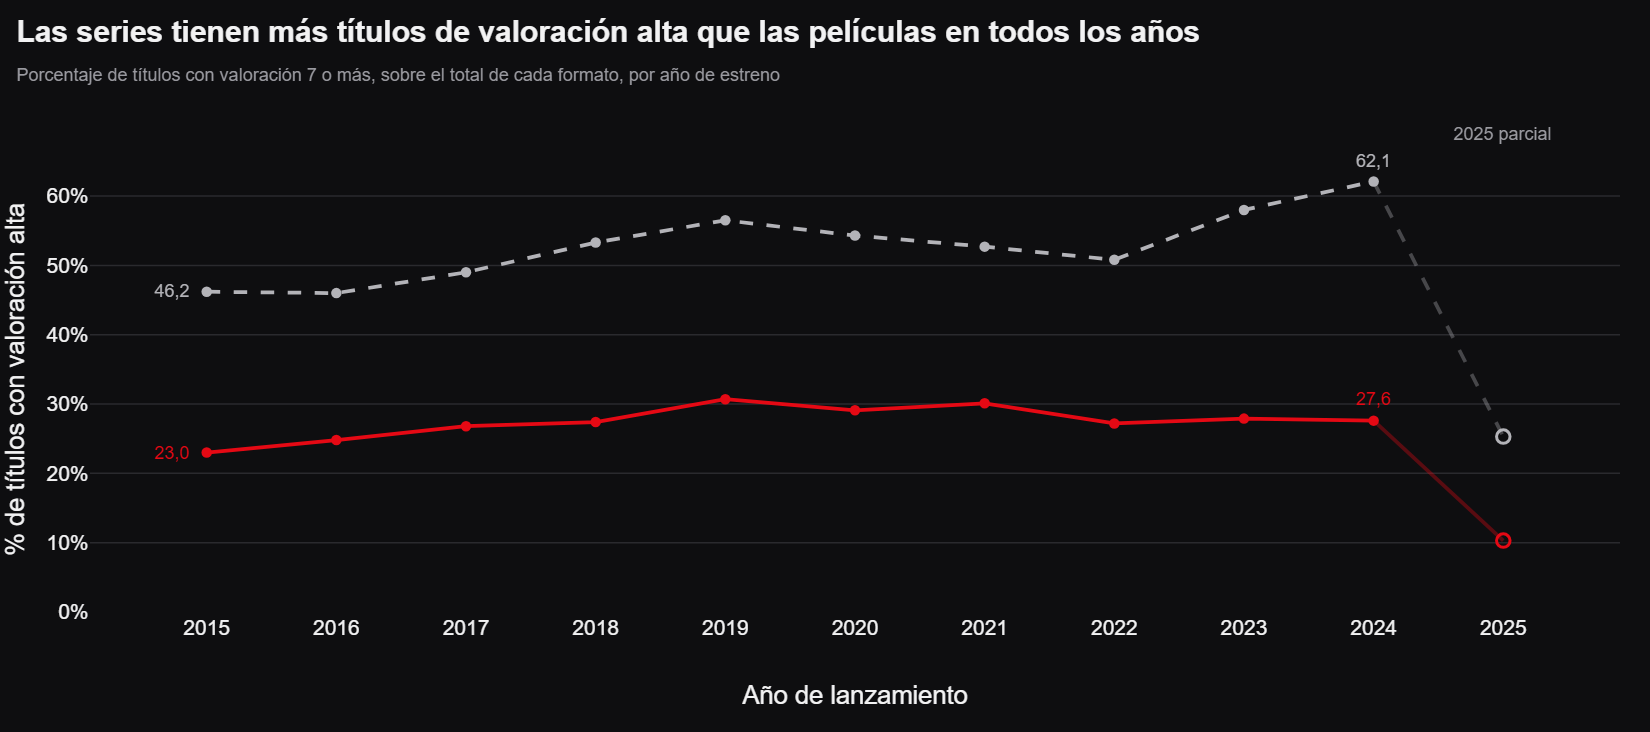

In [14]:
ventaja = metrics.ventaja_valoracion_alta_por_anio(df_def)
largo = ventaja.melt(id_vars="anio", value_vars=FORMATOS, var_name="type", value_name="valor").rename(columns={"anio": "release_year"})
largo["valor"] = largo["valor"] * 100
fig = charts.linea_evolucion(largo, "% de títulos con valoración alta", anio_parcial=anio_max)
fig.update_yaxes(ticksuffix="%", hoverformat=".1f")
mostrar(fig, "Las series tienen más títulos de valoración alta que las películas en todos los años",
        f"Porcentaje de títulos con valoración {metrics.UMBRAL_ALTA} o más, sobre el total de cada formato, por año de estreno")

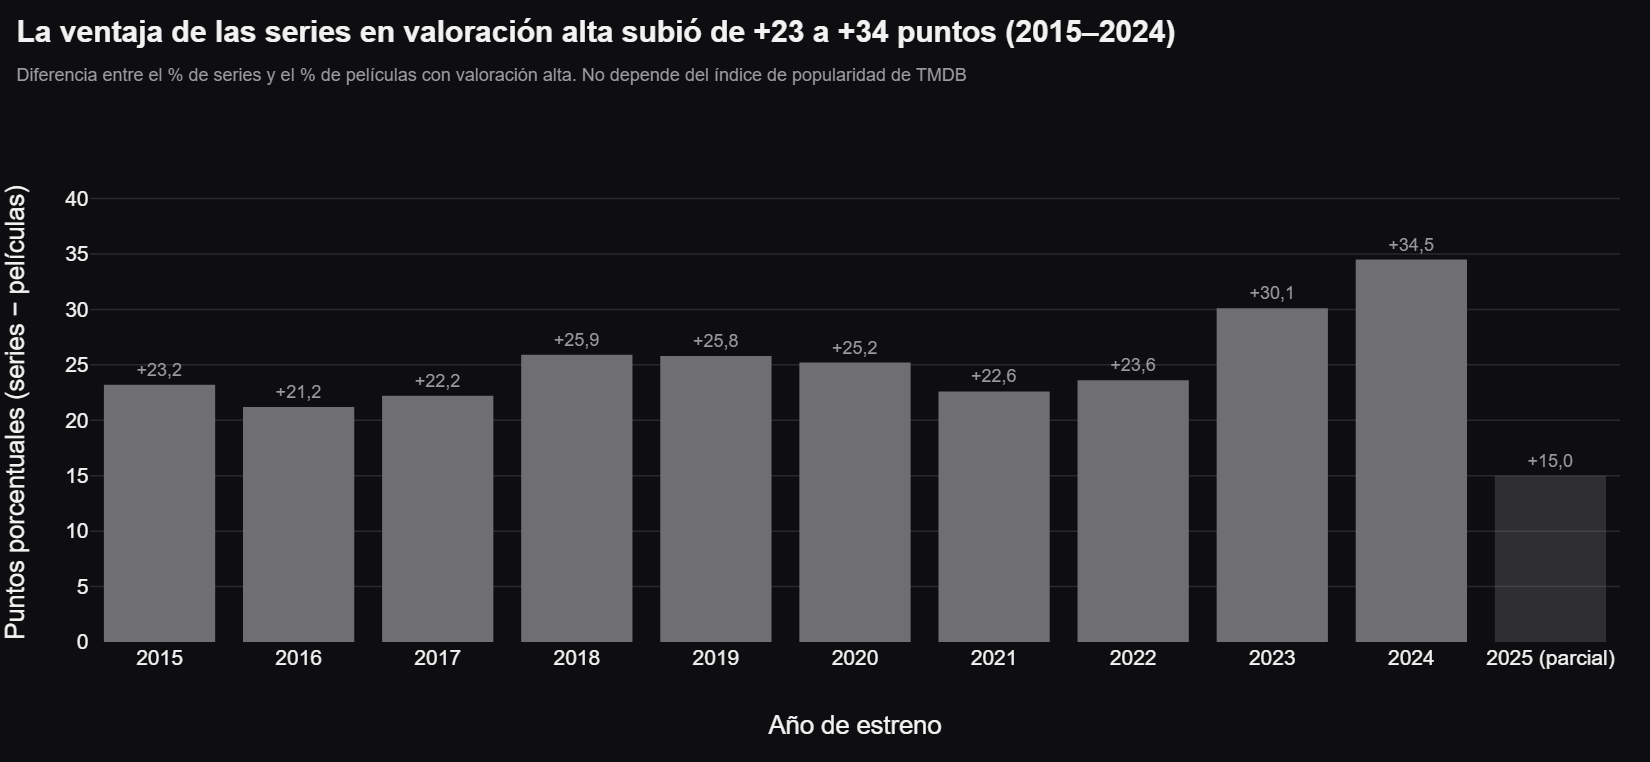

Años en que las series superan a las películas: 11 de 11


In [15]:
fig = go.Figure(go.Bar(
    x=ventaja["anio"], y=ventaja["ventaja_pp"], marker=dict(color=theme.NEUTRO, opacity=[0.35 if a == anio_max else 1 for a in ventaja["anio"]]),
    text=[f"+{theme.fmt_float(v)}" for v in ventaja["ventaja_pp"]], textposition="outside", textfont=dict(size=theme.TAM_CAPTION, color=theme.TEXT_MUTED),
    hovertemplate="%{x}: %{y:+.1f} puntos<extra></extra>", cliponaxis=False))
fig = base(fig, alto=400)
fig.update_xaxes(tickmode="array", tickvals=list(ventaja["anio"]), ticktext=[f"{a} (parcial)" if a == anio_max else str(a) for a in ventaja["anio"]], title_text="Año de estreno")
fig.update_yaxes(showgrid=True, range=[0, ventaja["ventaja_pp"].max() * 1.2], title_text="Puntos porcentuales (series − películas)")
mostrar(fig, f"La ventaja de las series en valoración alta subió de +{theme.fmt_float(t['pp_ini'], 0)} a +{theme.fmt_float(t['pp_fin'], 0)} puntos ({t['anio_ini']}–{t['anio_fin']})",
        "Diferencia entre el % de series y el % de películas con valoración alta. No depende del índice de popularidad de TMDB")
print(f"Años en que las series superan a las películas: {int((ventaja['ventaja_pp'] > 0).sum())} de {len(ventaja)}")

### D3. Popularidad relativa por género

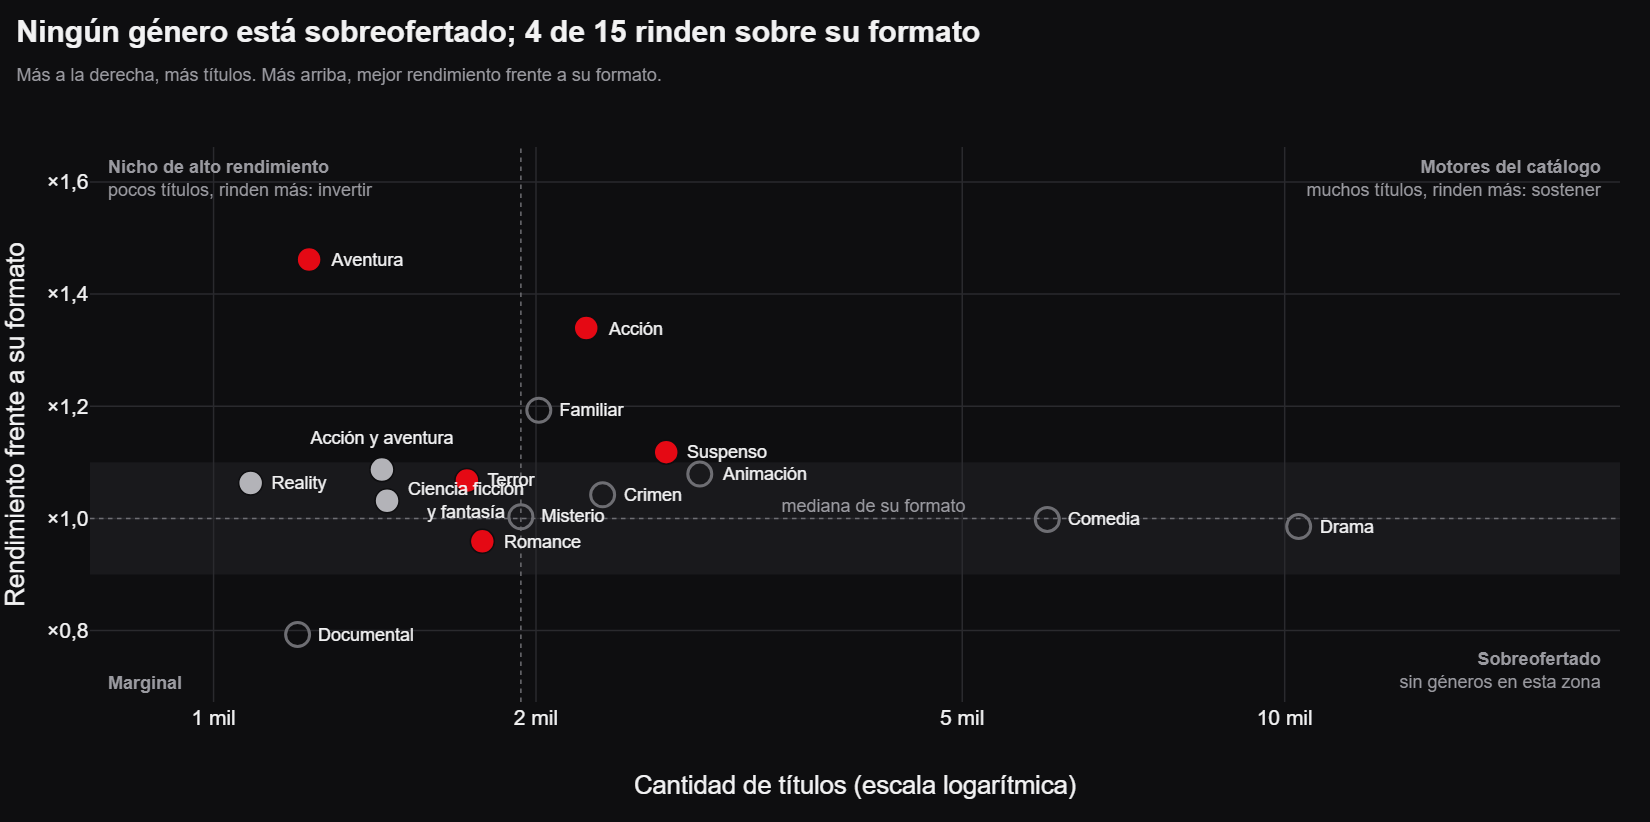

,Títulos,Popularidad relativa,Cuadrante,Película,Serie
Género,,,,,
Aventura,1.228,"1,46",Nicho de alto rendimiento,1228,0
Acción,2.228,"1,34",Motores del catálogo,2228,0
Familiar,2.012,"1,19",Motores del catálogo,994,1018
Suspenso,2.646,"1,12",Motores del catálogo,2646,0
Acción y aventura,1.436,"1,09",Rinde como su formato,0,1436
Animación,2.844,"1,08",Rinde como su formato,1067,1777
Terror,1.724,"1,07",Rinde como su formato,1724,0
Reality,1.083,"1,06",Rinde como su formato,0,1083
Crimen,2.308,"1,04",Rinde como su formato,1203,1105


In [16]:
resumen = metrics.resumen_generos(df_def)
cuadrantes, med_x, referencia = metrics.cuadrantes_generos(resumen)
mostrar(charts.burbujas_generos(cuadrantes, med_x, referencia), *narrative.titulo_generos(df_def))

tabla_generos = cuadrantes.sort_values("pop_relativa", ascending=False)[["genero", "titulos", "pop_relativa", "cuadrante", "Película", "Serie"]]
tabla_generos = tabla_generos.assign(titulos=tabla_generos["titulos"].map(theme.fmt_int), pop_relativa=tabla_generos["pop_relativa"].map(lambda v: theme.fmt_float(v, 2)))
tabla_generos.rename(columns={"genero": "Género", "titulos": "Títulos", "pop_relativa": "Popularidad relativa", "cuadrante": "Cuadrante"}).set_index("Género")

### D4. Popularidad relativa por país

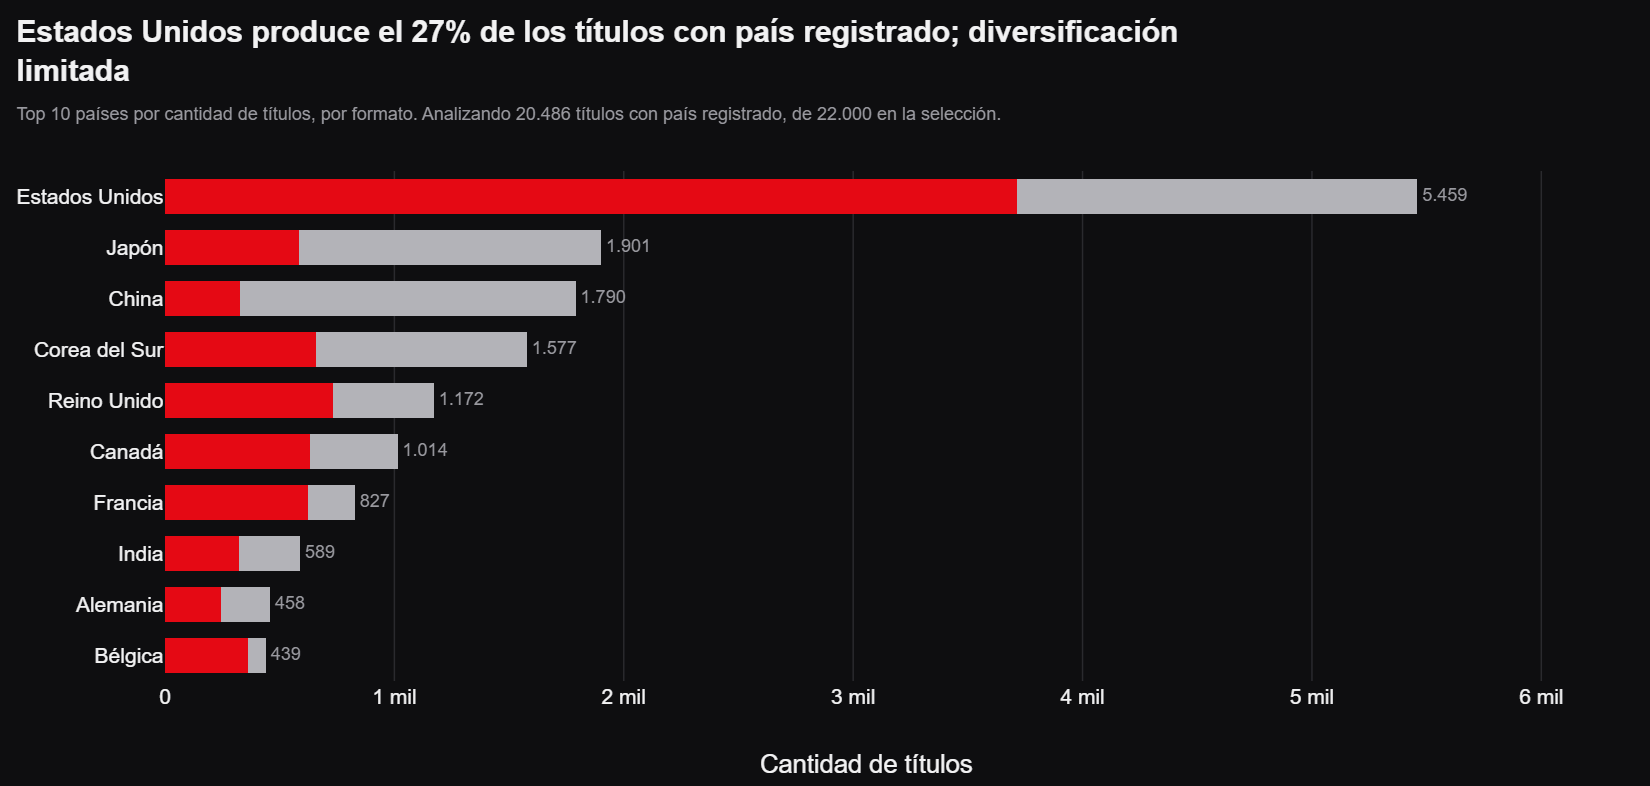

Países con al menos 150 títulos: 21. Los 3 primeros mercados (Estados Unidos, Japón y China) concentran el 45% de los títulos con país registrado.
Mercados destino (relativa > 1,0, fuera de los concentrados): Filipinas (1,41×) y México (1,22×)



,Títulos,Popularidad relativa,Popularidad mediana,% series
País,,,,
Filipinas,331,"1,41","37,9",63%
México,321,"1,22","29,2",54%
Estados Unidos,5.459,"1,11","19,8",32%
Turquía,273,"1,07","34,4",80%
Brasil,262,"1,06","29,9",59%
Canadá,1.014,"1,04","19,6",37%
Australia,286,"1,04","18,6",30%
Corea del Sur,1.577,"1,04","26,4",58%
España,439,"1,00","20,8",42%


In [17]:
datos_paises, orden_paises = metrics.top_paises(df_def, n=metrics.N_PAISES_RANKING, modo=metrics.MODO_PRIMER_PAIS)
relativa_paises = metrics.popularidad_relativa_paises(df_def, metrics.MODO_PRIMER_PAIS, min_titulos=1).set_index("pais")["pop_relativa"]
mostrar(charts.barras_paises_apiladas(datos_paises, orden_paises, relativa_paises), *narrative.titulo_paises(df_def, metrics.MODO_PRIMER_PAIS))

rel_paises = metrics.popularidad_relativa_paises(df_def, metrics.MODO_PRIMER_PAIS)  # solo países con al menos 150 títulos
lider = metrics.pais_lider(df_def, modo=metrics.MODO_PRIMER_PAIS)
destinos = metrics.destinos_mercados(df_def, metrics.MODO_PRIMER_PAIS)
print(f"Países con al menos {metrics.MIN_TITULOS_RELATIVA} títulos: {len(rel_paises)}. Los {len(lider['top'])} primeros mercados ({narrative.unir_es(lider['top'])}) concentran el {theme.fmt_pct(lider['pct_top'])} de los títulos con país registrado.")
print(f"Mercados destino (relativa > {theme.fmt_float(metrics.REFERENCIA_RELATIVA)}, fuera de los concentrados): {narrative.unir_es(d['pais'] + ' (' + theme.fmt_float(d['pop_relativa'], 2) + '×)' for d in destinos)}\n")
rel_paises.assign(titulos=rel_paises["titulos"].map(theme.fmt_int), pop_relativa=rel_paises["pop_relativa"].map(lambda v: theme.fmt_float(v, 2)),
                  pop_bruta=rel_paises["pop_bruta"].map(theme.fmt_float), pct_series=rel_paises["pct_series"].map(theme.fmt_pct)
                  ).rename(columns={"pais": "País", "titulos": "Títulos", "pop_relativa": "Popularidad relativa", "pop_bruta": "Popularidad mediana", "pct_series": "% series"}).set_index("País")

### La tesis, tal como la calcula el dashboard

In [18]:
resumen_dashboard = narrative.resumen_ejecutivo(df_def, (metrics.ANIO_INICIO_DEFECTO, anio_max), metrics.MODO_PRIMER_PAIS, anio_max)
print("TESIS:", textwrap.fill(resumen_dashboard["titular"], 110))
print(textwrap.fill(resumen_dashboard["soporte"], 110, initial_indent="  ", subsequent_indent="  "))
print("\nQUÉ HACER:")
for tarjeta in resumen_dashboard["tarjetas"]:
    print(textwrap.fill(f"• {tarjeta['numero']} · {tarjeta['accion']} — {tarjeta['respaldo']}", 110, subsequent_indent="  "))

TESIS: Las series rinden más que las películas y deben priorizarse
  Su ventaja en popularidad bajó de 4,4× a 1,2× (2015–2024), pero su ventaja en valoración alta subió de +23 a
  +34 puntos.

QUÉ HACER:
• +34 pp · Priorizar las series en las próximas licencias — Su ventaja en valoración alta llegó a +34 puntos
  en 2024.
• 3 · Priorizar Aventura, Acción y Suspenso al licenciar películas — Rinden 1,46×, 1,34× y 1,12× la mediana de
  las películas.
• 45% · Diversificar hacia Filipinas y México — Estados Unidos, Japón y China concentran el 45% de los títulos
  con país registrado. Filipinas y México rinden 1,41× y 1,22× la mediana de su formato.


### Conclusión D

**Qué se encontró.** Dos hechos, no uno, sostienen la prioridad de las series:
1. **En popularidad su ventaja se achica**: de 4,4× (2015) a 1,2× (2024). La razón cae en dos tramos: las series bajan 34 % en 2020 (de 45,9 a 30,3) y las películas suben de 10,3 a 27,7 entre 2020 y 2024. El 1,5× de 2025 no es una recuperación (año parcial). Parte del estrechamiento puede deberse a que el índice de TMDB favorece a los estrenos recientes de cine; los datos no permiten confirmarlo.
2. **En valoración alta su ventaja crece**: de +23 a +34 puntos (2015–2024), y las series superan a las películas en los once años. Esta medida no depende del índice de TMDB, por eso es la que sostiene la prioridad.

Entre géneros, **cuatro rinden sobre la mediana de su formato** (Aventura 1,46×, Acción 1,34×, Familiar 1,19×, Suspenso 1,12×), diez rinden como su formato, uno rinde bajo (Documental 0,79×) y **ninguno está sobreofertado**. Entre mercados, **Filipinas (1,41×) y México (1,22×)** rinden sobre su formato, y los tres primeros mercados concentran el 45 % de los títulos con país.

**Decisión de diseño.** La tesis del Resumen —«las series rinden más que las películas y deben priorizarse»— **se calcula, no se escribe**, y cita los dos hechos tal cual (la ventaja en popularidad bajó, pero la de valoración alta subió). De ahí salen las tres acciones de «Qué hacer»: *priorizar series* en las licencias; *elegir géneros que rinden sobre su formato al licenciar películas* (Aventura, Acción, Suspenso; Familiar rinde sobre su formato en ambos); y *diversificar hacia Filipinas y México* **sin recortar** los mercados actuales. Que el cuadrante «sobreofertado» esté vacío es un hallazgo y no se corrige moviendo el criterio: la banda de ±10 % en torno a 1,0 no se ajusta. Como no se midió retorno financiero, el dashboard nunca lo promete: habla de rendimiento relativo.

## De los hallazgos a las decisiones

| Hallazgo | Decisión en el dashboard | Dónde se ve |
|---|---|---|
| 1.000 títulos por año y formato (datos sintéticos) | No se analiza el volumen por año | «Sobre los datos», `docs/metodologia.md` |
| `rating` = `vote_average` | Se descarta `rating`; no hay análisis por edad | `docs/metodologia.md` |
| 20 de 28 géneros en un solo formato | Popularidad relativa a su formato; géneros sin fusionar; color por formato de origen | Géneros, «Sobre los datos» |
| 2025 con 68 % sin votos | Año parcial: se muestra, se marca y no entra a los extremos de tendencia | Evolución, Matriz, «Sobre los datos» |
| 7 % sin país y 17 % coproducciones | Dos modos de conteo; denominador «títulos con país registrado» | Mercados |
| `popularity` muy asimétrica | Mediana en vez de promedio; escala logarítmica en la Matriz | Todas las pestañas, Matriz |
| 14 % con `vote_average` = 0 | «Sin votos» aparte y rayado; cortes 4, 6 y 7; mínimo de votos | Valoración, Matriz, KPI |
| Ventaja en popularidad 4,4× → 1,2×; en valoración alta +23 → +34 | Tesis de dos hechos; series primero | Resumen, Evolución, Valoración |
| Géneros y mercados que rinden sobre su formato | Acciones 2 y 3 del Resumen | Resumen, Géneros, Mercados |

## Comprobación de las cifras citadas

Las celdas «Conclusión» citan cifras de esta ejecución. Esta celda las verifica: si los datos cambian, falla.

In [19]:
p = pc["parcial"]
gen = metrics.resumen_generos(df_def).set_index("genero")["pop_relativa"]
rel = metrics.popularidad_relativa_paises(df_def, metrics.MODO_PRIMER_PAIS).set_index("pais")["pop_relativa"]
pop = df["popularity"]
por_anio_ventaja = ventaja.set_index("anio")["ventaja_pp"]
verificaciones = {
    "32.000 títulos, 16.000 por formato, 2010–2025": len(df) == 32000 and pc["n_pelicula"] == pc["n_serie"] == 16000 and (pc["anio_min"], pc["anio_max"]) == (2010, 2025),
    "B1 · 1.000 títulos por año y formato": pc["uniforme"] and pc["filas_por_anio_formato"] == 1000,
    "B2 · rating idéntica a vote_average, numérica, 0 a 10": fuente["rating_numerico"] and fuente["rating_igual_vote_average"] and (fuente["rating_min"], fuente["rating_max"]) == (0, 10),
    "B3 · 20 de 28 géneros en un solo formato": len(pc["generos_un_formato"]) == 20 and pc["n_generos"] == 28,
    "B4 · 2025: 68 % sin votos frente a 11 %; popularidad 9,8 frente a 23,0": (round(p["pct_sin_votos"] * 100), round(p["pct_sin_votos_previos"] * 100), round(p["popularidad_mediana"], 1), round(p["popularidad_mediana_previos"], 1)) == (68, 11, 9.8, 23.0),
    "B4 · en 2025 ambos formatos tienen más de 3 veces el % sin votos de 2024": all(float(sin_votos[(sin_votos.release_year == anio_max) & (sin_votos.type == f)].valor.iloc[0]) > 3 * float(sin_votos[(sin_votos.release_year == anio_max - 1) & (sin_votos.type == f)].valor.iloc[0]) for f in FORMATOS),
    "B5 · 2.263 sin país (1.797 series, 466 películas) y 5.365 coproducciones": (pc["n_sin_pais"], pc["n_multipais"], int(conteo.loc["Sin país", "Serie"]), int(conteo.loc["Sin país", "Película"])) == (2263, 5365, 1797, 466),
    "C1 · promedio 42,6, mediana 22,1, asimetría 20, 24 % sobre el promedio": (round(pop.mean(), 1), round(pop.median(), 1), round(pop.skew()), round((pop > pop.mean()).mean() * 100)) == (42.6, 22.1, 20, 24),
    "C2 · 14 % con valoración 0; 4.555 coinciden con vote_count 0 y solo 30 difieren (17 + 13)": (round(pct_cero * 100), int(((df["vote_average"] == 0) & (df["vote_count"] == 0)).sum()), int(((df["vote_average"] == 0) & (df["vote_count"] > 0)).sum()), int(((df["vote_average"] > 0) & (df["vote_count"] == 0)).sum())) == (14, 4555, 17, 13),
    "D1 · razón 4,4× → 1,2× (2015–2024); series −34 % en 2020": (round(t["razon_ini"], 1), round(t["razon_fin"], 1), t["anio_ini"], t["anio_fin"], round(t["tramo_series"]["var"] * 100)) == (4.4, 1.2, 2015, 2024, -34),
    "D1 · películas 10,3 → 27,7 entre 2020 y 2024": (round(t["tramo_peliculas"]["de"], 1), round(t["tramo_peliculas"]["a"], 1)) == (10.3, 27.7),
    "D2 · ventaja +23 → +34 puntos y positiva los 11 años": (round(t["pp_ini"]), round(t["pp_fin"]), int((por_anio_ventaja > 0).sum())) == (23, 34, 11),
    "D3 · Aventura 1,46 · Acción 1,34 · Familiar 1,19 · Suspenso 1,12 · Documental 0,79": [round(gen[g], 2) for g in ("Aventura", "Acción", "Familiar", "Suspenso", "Documental")] == [1.46, 1.34, 1.19, 1.12, 0.79],
    "D3 · 4 sobre su formato, 10 dentro de la banda, 1 bajo, 0 sobreofertados": (int(cuadrantes["cuadrante"].isin([metrics.CUAD_MOTORES, metrics.CUAD_NICHO]).sum()), int((cuadrantes["cuadrante"] == metrics.CUAD_EN_MEDIANA).sum()), int((cuadrantes["cuadrante"] == metrics.CUAD_MARGINAL).sum()), int((cuadrantes["cuadrante"] == metrics.CUAD_SOBREOFERTADO).sum())) == (4, 10, 1, 0),
    "D4 · Filipinas 1,41 · México 1,22; los 3 primeros mercados suman 45 %": (round(rel["Filipinas"], 2), round(rel["México"], 2), round(lider["pct_top"] * 100)) == (1.41, 1.22, 45),
    "Tesis calculada por el dashboard": resumen_dashboard["titular"] == "Las series rinden más que las películas y deben priorizarse",
}
for nombre, ok in verificaciones.items():
    print("✔" if ok else "✘", nombre)
assert all(verificaciones.values()), "Alguna cifra citada en las conclusiones ya no coincide con los datos: actualiza la celda Conclusión."
print(f"\n{len(verificaciones)} de {len(verificaciones)} cifras verificadas.")

✔ 32.000 títulos, 16.000 por formato, 2010–2025
✔ B1 · 1.000 títulos por año y formato
✔ B2 · rating idéntica a vote_average, numérica, 0 a 10
✔ B3 · 20 de 28 géneros en un solo formato
✔ B4 · 2025: 68 % sin votos frente a 11 %; popularidad 9,8 frente a 23,0
✔ B4 · en 2025 ambos formatos tienen más de 3 veces el % sin votos de 2024
✔ B5 · 2.263 sin país (1.797 series, 466 películas) y 5.365 coproducciones
✔ C1 · promedio 42,6, mediana 22,1, asimetría 20, 24 % sobre el promedio
✔ C2 · 14 % con valoración 0; 4.555 coinciden con vote_count 0 y solo 30 difieren (17 + 13)
✔ D1 · razón 4,4× → 1,2× (2015–2024); series −34 % en 2020
✔ D1 · películas 10,3 → 27,7 entre 2020 y 2024
✔ D2 · ventaja +23 → +34 puntos y positiva los 11 años
✔ D3 · Aventura 1,46 · Acción 1,34 · Familiar 1,19 · Suspenso 1,12 · Documental 0,79
✔ D3 · 4 sobre su formato, 10 dentro de la banda, 1 bajo, 0 sobreofertados
✔ D4 · Filipinas 1,41 · México 1,22; los 3 primeros mercados suman 45 %
✔ Tesis calculada por el dashboar